In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import time

# Config
IMG_SIZE     = 224
PATCH_SIZE   = 16
NUM_PATCHES  = (IMG_SIZE // PATCH_SIZE) ** 2  # 196
MASK_RATIO   = 0.75
NUM_VISIBLE  = int(NUM_PATCHES * (1 - MASK_RATIO))  # 49
NUM_MASKED   = NUM_PATCHES - NUM_VISIBLE              # 147
BATCH_SIZE   = 32
EPOCHS       = 20
LR           = 1.5e-4
WEIGHT_DECAY = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPUs available :", torch.cuda.device_count())
print("Device         :", device)
print(f"Patches  →  Total:{NUM_PATCHES}  Visible:{NUM_VISIBLE}  Masked:{NUM_MASKED}")

GPUs available : 2
Device         : cuda
Patches  →  Total:196  Visible:49  Masked:147


In [2]:
import os

print("=== Searching for dataset ===")
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    if root.count(os.sep) > 7:
        break

=== Searching for dataset ===
/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/akash2sharma
/kaggle/input/datasets/akash2sharma/tiny-imagenet
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/tiny-imagenet-200
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/tiny-imagenet-200/val


In [3]:
class TinyImageNetDataset(Dataset):
    def __init__(self, root, split='train', transform=None):
        self.transform = transform
        self.samples   = []
        path = os.path.join(root, split)
        print(f"Loading {split} from: {path}")

        if split == 'train':
            for cls in os.listdir(path):
                img_dir = os.path.join(path, cls, 'images')
                if os.path.isdir(img_dir):
                    for f in os.listdir(img_dir):
                        if f.lower().endswith(('.jpeg','.jpg','.png')):
                            self.samples.append(os.path.join(img_dir, f))
        else:
            img_dir = os.path.join(path, 'images')
            if os.path.isdir(img_dir):
                src = img_dir
            else:
                src = path
            for f in os.listdir(src):
                if f.lower().endswith(('.jpeg','.jpg','.png')):
                    self.samples.append(os.path.join(src, f))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, 0


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225]),
])

ROOT = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/tiny-imagenet-200'

train_dataset = TinyImageNetDataset(ROOT, 'train', transform)
val_dataset   = TinyImageNetDataset(ROOT, 'val',   transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

print(f"Train samples : {len(train_dataset)}")
print(f"Val   samples : {len(val_dataset)}")

Loading train from: /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/tiny-imagenet-200/train
Loading val from: /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/tiny-imagenet-200/val
Train samples : 100000
Val   samples : 10000


In [4]:
def patchify(imgs, patch_size=PATCH_SIZE):
    B, C, H, W = imgs.shape
    h = w = H // patch_size
    x = imgs.reshape(B, C, h, patch_size, w, patch_size)
    x = torch.einsum('bchpwq->bhwpqc', x)
    return x.reshape(B, h * w, patch_size * patch_size * C)


def unpatchify(patches, patch_size=PATCH_SIZE, img_size=IMG_SIZE):
    B, N, D = patches.shape
    h = w = img_size // patch_size
    C = D // (patch_size * patch_size)
    x = patches.reshape(B, h, w, patch_size, patch_size, C)
    x = torch.einsum('bhwpqc->bchpwq', x)
    return x.reshape(B, C, img_size, img_size)


def random_masking(x, mask_ratio=MASK_RATIO):
    B, N, D  = x.shape
    num_keep = int(N * (1 - mask_ratio))

    noise       = torch.rand(B, N, device=x.device)
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep    = ids_shuffle[:, :num_keep]

    x_visible = torch.gather(
        x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))

    mask = torch.ones(B, N, device=x.device)
    mask[:, :num_keep] = 0
    mask = torch.gather(mask, 1, ids_restore)

    return x_visible, mask, ids_restore, ids_keep


# Quick test
imgs, _ = next(iter(train_loader))
patches = patchify(imgs)
x_vis, mask, ids_restore, ids_keep = random_masking(patches)

print("Original image :", imgs.shape)
print("Patches        :", patches.shape)
print("Visible patches:", x_vis.shape)
print("Masked count   :", int(mask[0].sum()))

Original image : torch.Size([32, 3, 224, 224])
Patches        : torch.Size([32, 196, 768])
Visible patches: torch.Size([32, 49, 768])
Masked count   : 147


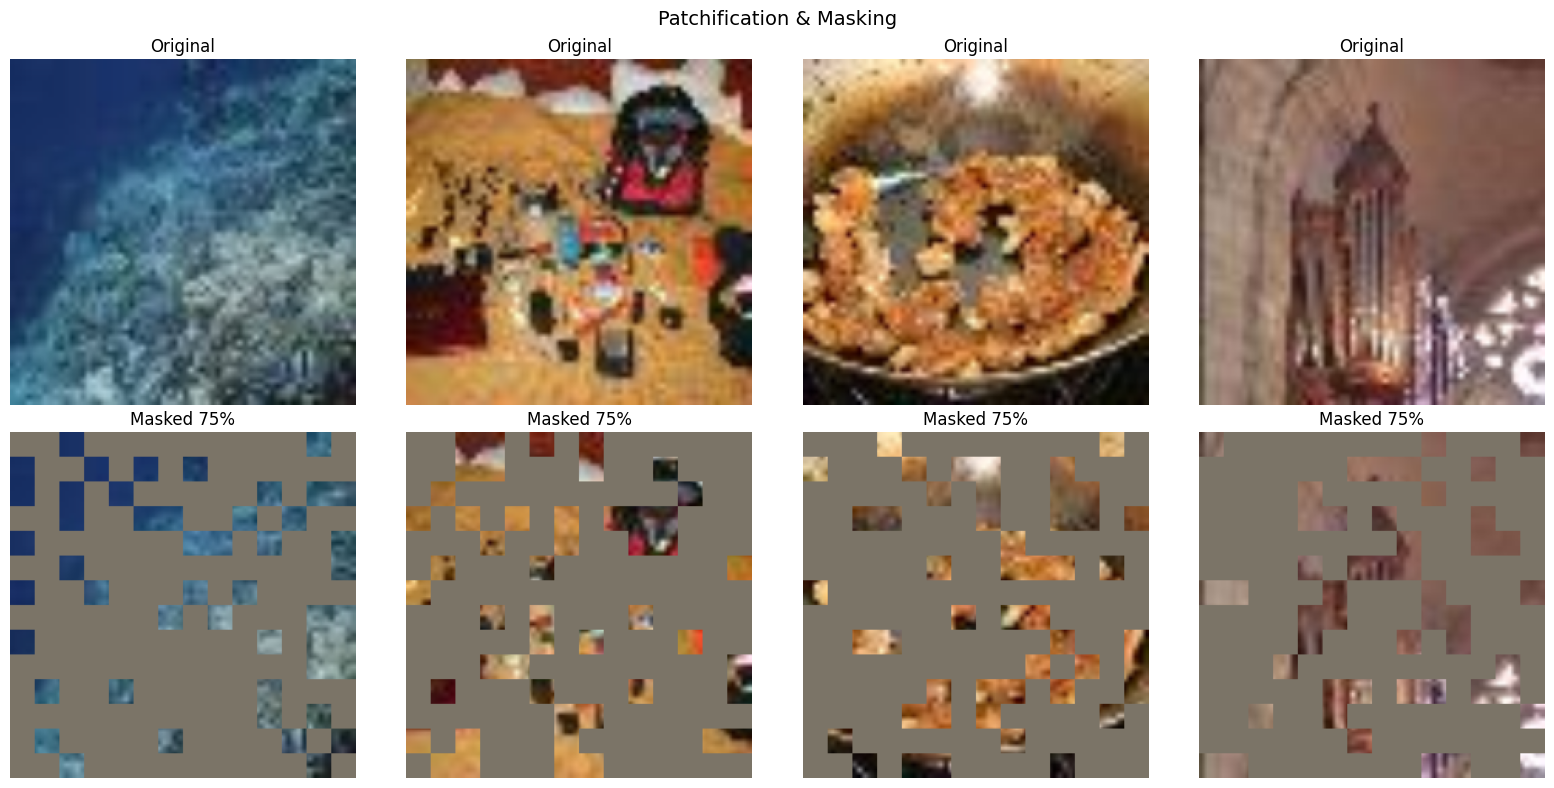

Done - masking_viz.png saved


In [5]:
_mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
_std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

def denorm(t):
    return ((t.cpu() * _std + _mean).clamp(0,1)
            .permute(1,2,0).numpy())

# Build masked image for display
masked_p = patches.clone()
masked_p[mask.bool()] = 0
masked_imgs = unpatchify(masked_p)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    axes[0,i].imshow(denorm(imgs[i]))
    axes[0,i].set_title("Original")
    axes[0,i].axis('off')
    axes[1,i].imshow(denorm(masked_imgs[i]))
    axes[1,i].set_title("Masked 75%")
    axes[1,i].axis('off')

plt.suptitle("Patchification & Masking", fontsize=14)
plt.tight_layout()
plt.savefig('masking_viz.png', dpi=150)
plt.show()
print("Done - masking_viz.png saved")

In [6]:
def get_2d_sincos_pos_embed(embed_dim, grid_size):
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid   = np.stack(np.meshgrid(grid_w, grid_h), axis=0).reshape(2, -1)

    omega  = np.arange(embed_dim // 4, dtype=np.float32) / (embed_dim / 4)
    omega  = 1.0 / (10000 ** omega)

    def enc1d(pos, d):
        out = np.outer(pos, d)
        return np.concatenate([np.sin(out), np.cos(out)], axis=1)

    emb = np.concatenate([enc1d(grid[0], omega),
                          enc1d(grid[1], omega)], axis=1)
    return torch.from_numpy(emb).float()


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hid = int(dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, hid), nn.GELU(), nn.Linear(hid, dim)
        )

    def forward(self, x):
        h, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + h
        x = x + self.mlp(self.norm2(x))
        return x


# Test
pos = get_2d_sincos_pos_embed(768, 14)
print("Pos embed shape:", pos.shape)

blk = TransformerBlock(768, 12)
dummy = torch.randn(2, 50, 768)
out = blk(dummy)
print("Block output   :", out.shape)

Pos embed shape: torch.Size([196, 768])
Block output   : torch.Size([2, 50, 768])


In [7]:
class MAEEncoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3,
                 embed_dim=768, depth=12, num_heads=12):
        super().__init__()
        self.embed_dim   = embed_dim
        self.num_patches = (img_size // patch_size) ** 2

        self.patch_proj = nn.Linear(patch_size * patch_size * in_chans, embed_dim)
        self.cls_token  = nn.Parameter(torch.zeros(1, 1, embed_dim))

        pos = get_2d_sincos_pos_embed(embed_dim, img_size // patch_size)
        self.register_buffer('pos_embed', pos.unsqueeze(0))

        self.blocks = nn.Sequential(
            *[TransformerBlock(embed_dim, num_heads) for _ in range(depth)]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, patches, ids_keep):
        x = self.patch_proj(patches) + self.pos_embed
        x = torch.gather(x, 1,
                ids_keep.unsqueeze(-1).expand(-1, -1, self.embed_dim))
        cls = self.cls_token.expand(x.shape[0], -1, -1)
        x   = torch.cat([cls, x], dim=1)
        return self.norm(self.blocks(x))


# Test
encoder  = MAEEncoder().to(device)
enc_out  = encoder(patches.to(device), ids_keep.to(device))
print("Encoder output :", enc_out.shape)
print("Encoder params :", sum(p.numel() for p in encoder.parameters())/1e6, "M")

Encoder output : torch.Size([32, 50, 768])
Encoder params : 85.64736 M


In [8]:
class MAEDecoder(nn.Module):
    def __init__(self, num_patches=196, patch_size=16, in_chans=3,
                 enc_dim=768, dec_dim=384, depth=12, num_heads=6):
        super().__init__()
        self.patch_dim = patch_size * patch_size * in_chans

        self.proj       = nn.Linear(enc_dim, dec_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_dim))

        grid    = int(num_patches ** 0.5)
        pos     = get_2d_sincos_pos_embed(dec_dim, grid)
        cls_pos = torch.zeros(1, dec_dim)
        full_pos = torch.cat([cls_pos.unsqueeze(0),
                               pos.unsqueeze(0)], dim=1)
        self.register_buffer('pos_embed', full_pos)

        self.blocks = nn.Sequential(
            *[TransformerBlock(dec_dim, num_heads) for _ in range(depth)]
        )
        self.norm = nn.LayerNorm(dec_dim)
        self.head = nn.Linear(dec_dim, self.patch_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.mask_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, latent, ids_restore):
        B, N = ids_restore.shape
        D    = self.proj.out_features

        x        = self.proj(latent)
        cls      = x[:, :1, :]
        x_vis    = x[:, 1:, :]

        num_mask    = N - x_vis.shape[1]
        mask_tokens = self.mask_token.expand(B, num_mask, -1)

        x_full = torch.cat([x_vis, mask_tokens], dim=1)
        x_full = torch.gather(x_full, 1,
                     ids_restore.unsqueeze(-1).expand(-1, -1, D))

        x_full = torch.cat([cls, x_full], dim=1)
        x_full = x_full + self.pos_embed
        x_full = self.norm(self.blocks(x_full))

        return self.head(x_full[:, 1:])


# Test
decoder  = MAEDecoder().to(device)
dec_out  = decoder(enc_out, ids_restore.to(device))
print("Decoder output :", dec_out.shape)
print("Decoder params :", sum(p.numel() for p in decoder.parameters())/1e6, "M")

Decoder output : torch.Size([32, 196, 768])
Decoder params : 21.885696 M


In [9]:
class MAE(nn.Module):
    def __init__(self, mask_ratio=0.75):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.encoder    = MAEEncoder()
        self.decoder    = MAEDecoder()

    def forward(self, imgs):
        patches = patchify(imgs)
        x_vis, mask, ids_restore, ids_keep = random_masking(
            patches, self.mask_ratio)

        latent = self.encoder(patches, ids_keep)
        pred   = self.decoder(latent, ids_restore)

        return pred, mask, patches


def mae_loss(pred, target, mask):
    """MSE loss only on masked patches"""
    loss = ((pred - target) ** 2).mean(dim=-1)   # (B, N)
    loss = (loss * mask).sum() / mask.sum()
    return loss


# Build model with multi-GPU support
model = MAE().to(device)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

# Sanity check — correct args this time
dummy = torch.randn(2, 3, 224, 224).to(device)
pred, mask, patches = model(dummy)
loss = mae_loss(pred, patches, mask)   # fixed: pred, patches, mask

print("pred shape   :", pred.shape)
print("mask shape   :", mask.shape)
print("patches shape:", patches.shape)
print("loss         :", round(loss.item(), 4))
print("Model ready!")

Using 2 GPUs!
pred shape   : torch.Size([2, 196, 768])
mask shape   : torch.Size([2, 196])
patches shape: torch.Size([2, 196, 768])
loss         : 1.6726
Model ready!


In [10]:
!pip install tqdm -q

from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm

optimizer = torch.optim.AdamW(model.parameters(),
                               lr=LR,
                               weight_decay=WEIGHT_DECAY,
                               betas=(0.9, 0.95))
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = GradScaler('cuda')

train_losses = []
val_losses   = []
best_val     = float('inf')
start_epoch  = 1

# ── Auto Resume if checkpoint exists ─────────────────────────
if os.path.exists('mae_checkpoint.pth'):
    print("Resuming from checkpoint...")
    ckpt = torch.load('mae_checkpoint.pth', map_location=device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    start_epoch  = ckpt['epoch'] + 1
    best_val     = ckpt['best_val']
    train_losses = ckpt['train_losses']
    val_losses   = ckpt['val_losses']
    print(f"Resumed from epoch {ckpt['epoch']} | Best Val: {best_val:.4f}")
else:
    print("Starting fresh training...")

print(f"Training from epoch {start_epoch} to {EPOCHS}")
print(f"{'='*60}")

for epoch in range(start_epoch, EPOCHS + 1):
    t0 = time.time()

    # ── Train ──────────────────────────────────────────────
    model.train()
    tr_loss = 0
    pbar = tqdm(train_loader,
                desc=f"Epoch [{epoch:2d}/{EPOCHS}] Train",
                leave=False)

    for imgs, _ in pbar:
        imgs = imgs.to(device, non_blocking=True)
        optimizer.zero_grad()

        with autocast('cuda'):
            pred, mask, patches = model(imgs)
            loss = mae_loss(pred, patches, mask)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        tr_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    # ── Validate ───────────────────────────────────────────
    model.eval()
    vl_loss = 0
    vbar = tqdm(val_loader,
                desc=f"Epoch [{epoch:2d}/{EPOCHS}] Val  ",
                leave=False)

    with torch.no_grad():
        for imgs, _ in vbar:
            imgs = imgs.to(device, non_blocking=True)
            with autocast('cuda'):
                pred, mask, patches = model(imgs)
                l = mae_loss(pred, patches, mask)
                vl_loss += l.item()
                vbar.set_postfix({'loss': f'{l.item():.4f}'})

    tr_loss /= len(train_loader)
    vl_loss /= len(val_loader)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    scheduler.step()

    elapsed = time.time() - t0
    print(f"Epoch [{epoch:2d}/{EPOCHS}] "
          f"Train: {tr_loss:.4f} | "
          f"Val: {vl_loss:.4f} | "
          f"LR: {scheduler.get_last_lr()[0]:.1e} | "
          f"Time: {elapsed:.1f}s")

    if vl_loss < best_val:
        best_val = vl_loss
        torch.save(model.state_dict(), 'mae_best.pth')
        print(f"  ✓ Best model saved (val={best_val:.4f})")

    # save checkpoint every epoch
    torch.save({
        'epoch'       : epoch,
        'model'       : model.state_dict(),
        'optimizer'   : optimizer.state_dict(),
        'scheduler'   : scheduler.state_dict(),
        'best_val'    : best_val,
        'train_losses': train_losses,
        'val_losses'  : val_losses,
    }, 'mae_checkpoint.pth')

print(f"{'='*60}")
print(f"Training complete! Best Val Loss: {best_val:.4f}")

^C
ERROR: Operation cancelled by user
Starting fresh training...
Training from epoch 1 to 20


KeyboardInterrupt: 

In [14]:
model.load_state_dict(torch.load(
    '/kaggle/input/notebooks/bilalchohan/genai-assignmnent-2/mae_best.pth',
    map_location=device))
print("Model loaded successfully!")

Model loaded successfully!


In [16]:
# Only run if you get NameError
checkpoint = torch.load(
    '/kaggle/input/notebooks/bilalchohan/genai-assignmnent-2/mae_checkpoint.pth',
    map_location=device)
train_losses = checkpoint['train_losses']
val_losses   = checkpoint['val_losses']
print("Losses loaded! Epochs:", len(train_losses))

Losses loaded! Epochs: 20


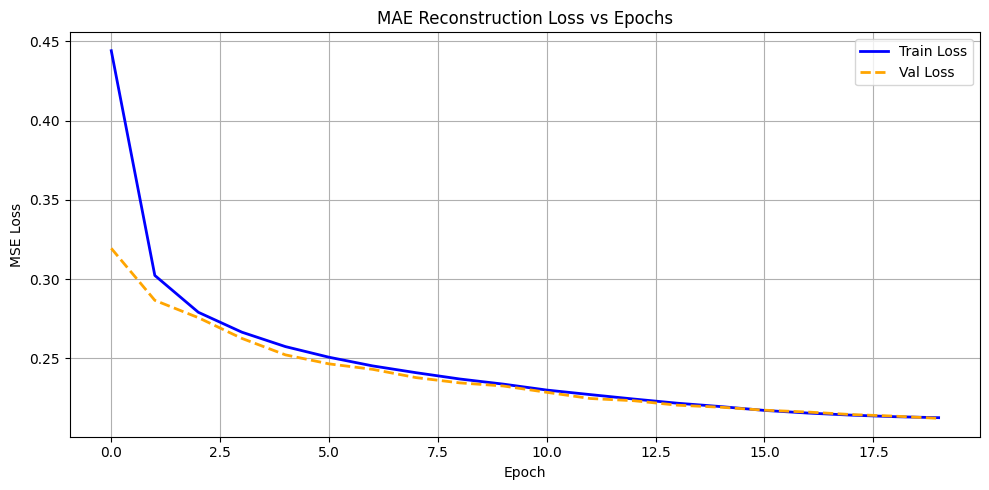

Best Train Loss: 0.2125
Best Val Loss  : 0.2121


In [17]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2, color='blue')
plt.plot(val_losses,   label='Val Loss',   linewidth=2, color='orange', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('MAE Reconstruction Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print("Best Train Loss:", round(min(train_losses), 4))
print("Best Val Loss  :", round(min(val_losses), 4))

Avg PSNR : 21.82 dB
Avg SSIM : 0.6948
Samples  : 224


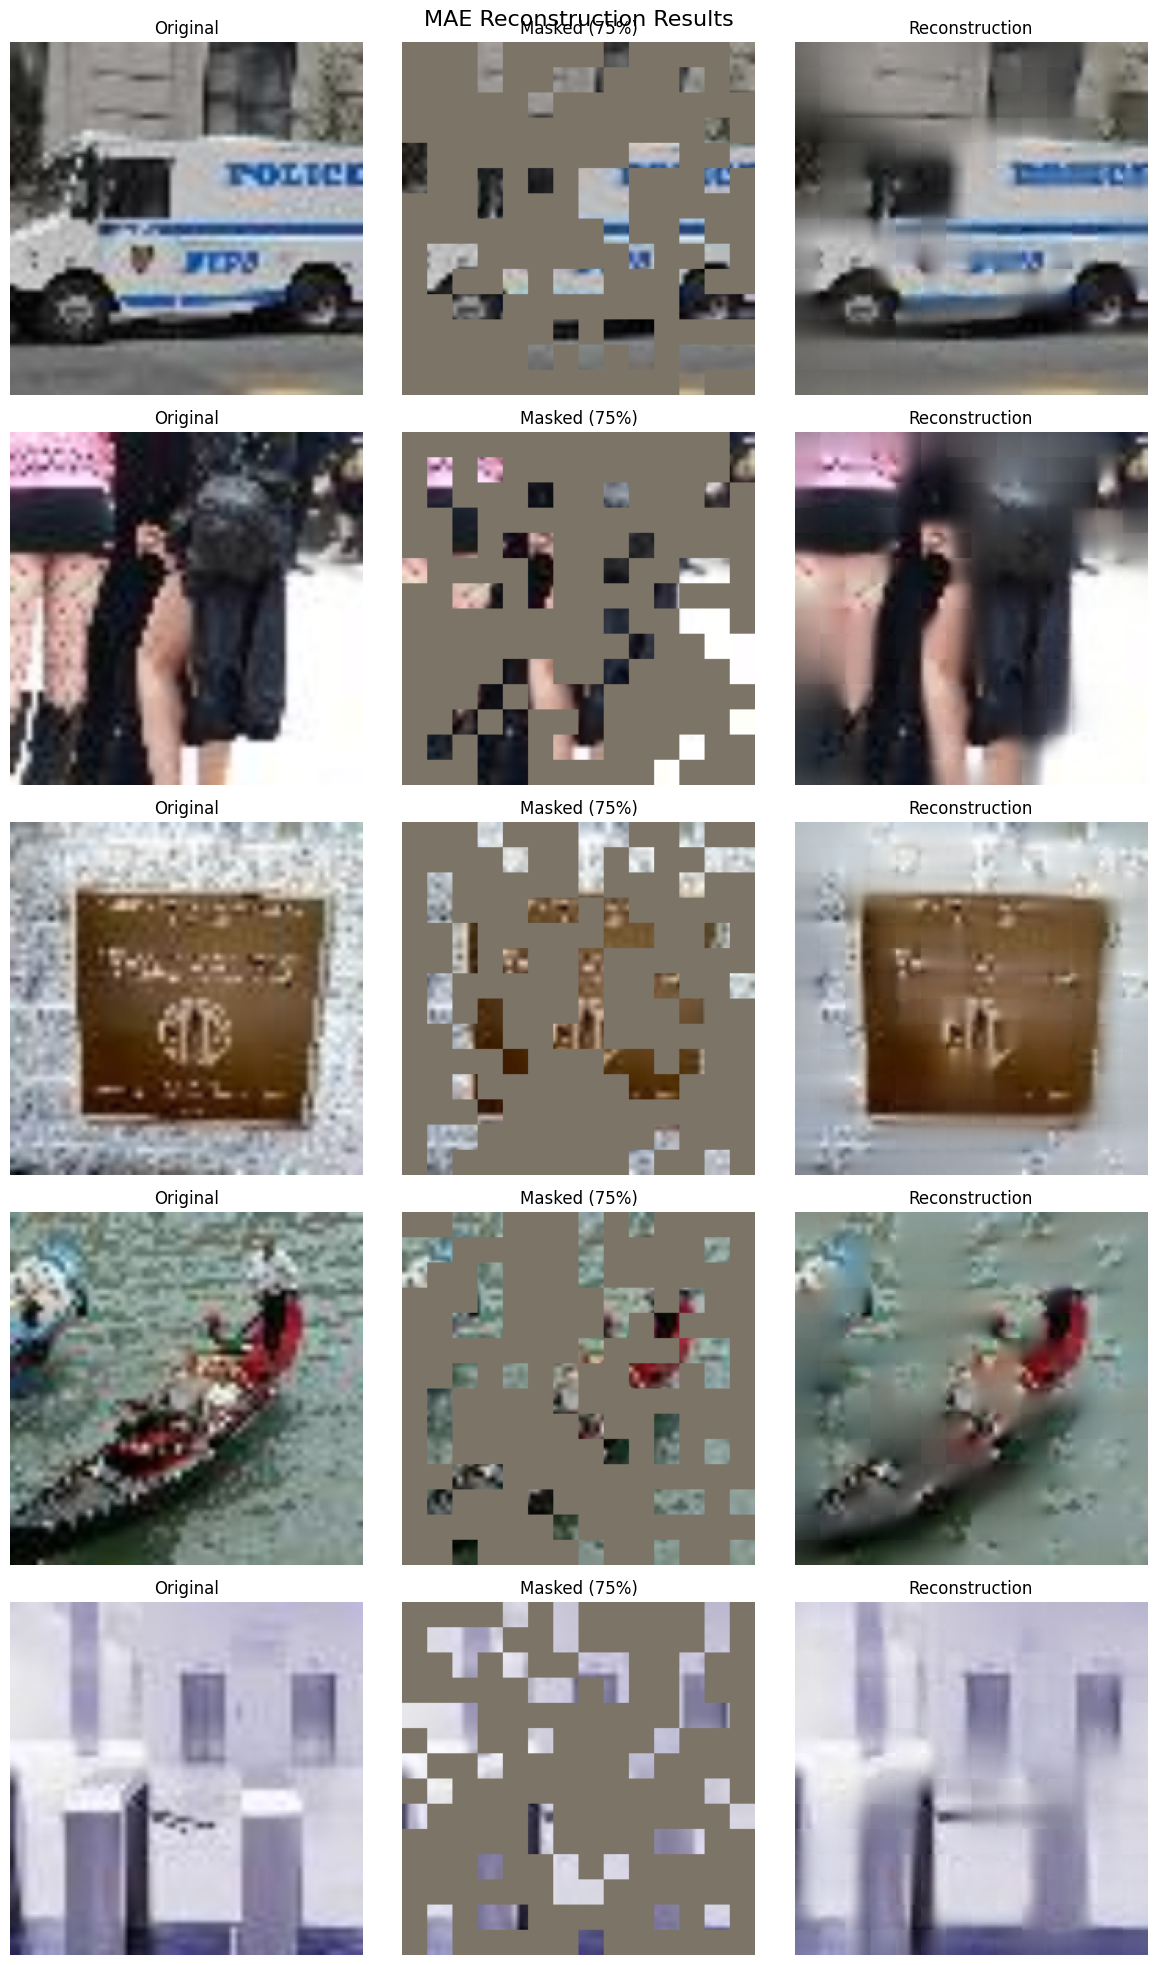

Saved reconstruction_samples.png


In [18]:
!pip install scikit-image -q

from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity   as calc_ssim

_mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
_std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

def denorm(t):
    return ((t.cpu() * _std + _mean).clamp(0,1)
            .permute(1,2,0).numpy())

model.eval()
psnr_list, ssim_list         = [], []
vis_orig, vis_mask, vis_recon = [], [], []

with torch.no_grad():
    for imgs, _ in val_loader:
        imgs = imgs.to(device)
        pred, mask, patches = model(imgs)
        mb = mask.bool()

        recon_p = patches.clone()
        recon_p[mb] = pred[mb]

        mask_p  = patches.clone()
        mask_p[mb] = 0

        recon_imgs = unpatchify(recon_p.cpu())
        mask_imgs  = unpatchify(mask_p.cpu())

        for i in range(imgs.shape[0]):
            o = denorm(imgs[i].cpu())
            r = denorm(recon_imgs[i])
            psnr_list.append(calc_psnr(o, r, data_range=1.0))
            ssim_list.append(calc_ssim(o, r, data_range=1.0,
                                       channel_axis=2))
            if len(vis_orig) < 5:
                vis_orig.append(o)
                vis_mask.append(denorm(mask_imgs[i]))
                vis_recon.append(r)

        if len(psnr_list) >= 200:
            break

print(f"{'='*40}")
print(f"Avg PSNR : {np.mean(psnr_list):.2f} dB")
print(f"Avg SSIM : {np.mean(ssim_list):.4f}")
print(f"Samples  : {len(psnr_list)}")
print(f"{'='*40}")

# Plot 5 samples
fig, axes = plt.subplots(5, 3, figsize=(12, 20))
titles = ['Original', 'Masked (75%)', 'Reconstruction']

for row in range(5):
    for col, (img, title) in enumerate(zip(
        [vis_orig[row], vis_mask[row], vis_recon[row]], titles)):
        axes[row, col].imshow(img.clip(0, 1))
        axes[row, col].set_title(title, fontsize=12)
        axes[row, col].axis('off')

plt.suptitle('MAE Reconstruction Results', fontsize=16)
plt.tight_layout()
plt.savefig('reconstruction_samples.png', dpi=150)
plt.show()
print("Saved reconstruction_samples.png")

In [24]:
!pip install gradio -q

import gradio as gr

def reconstruct(pil_img, mask_pct):
    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225]),
    ])

    img_t = tf(pil_img).unsqueeze(0).to(device)
    ratio = float(mask_pct) / 100.0

    model.eval()
    with torch.no_grad():
        patches  = patchify(img_t)
        x_vis, mask, ids_restore, ids_keep = random_masking(patches, ratio)

        core   = model.module if hasattr(model, 'module') else model
        latent = core.encoder(patches, ids_keep)
        pred   = core.decoder(latent, ids_restore)

    mb = mask.bool()

    recon_p = patches.clone()
    recon_p[mb] = pred[mb]

    mask_p = patches.clone()
    mask_p[mb] = 0

    def to_pil(t):
        arr = ((t.cpu() * _std + _mean)
               .clamp(0, 1)
               .permute(1, 2, 0)
               .numpy() * 255).astype(np.uint8)
        return Image.fromarray(arr)

    orig_pil  = to_pil(img_t[0])
    mask_pil  = to_pil(unpatchify(mask_p)[0])
    recon_pil = to_pil(unpatchify(recon_p)[0])

    return orig_pil, mask_pil, recon_pil


with gr.Blocks(title="MAE Reconstruction") as demo:
    gr.Markdown("# Masked Autoencoder - Image Reconstruction")
    gr.Markdown("Upload an image, select masking ratio, see reconstruction!")

    with gr.Row():
        with gr.Column():
            inp    = gr.Image(type="pil", label="Upload Image")
            slider = gr.Slider(minimum=10, maximum=90,
                               value=75, step=5,
                               label="Masking Ratio (%)")
            btn    = gr.Button("Reconstruct", variant="primary")

        with gr.Column():
            with gr.Row():
                out1 = gr.Image(label="Original")
                out2 = gr.Image(label="Masked Input")
                out3 = gr.Image(label="Reconstruction")

    btn.click(fn=reconstruct,
              inputs=[inp, slider],
              outputs=[out1, out2, out3])

demo.launch(share=True, debug=False)

* Running on local URL:  http://127.0.0.1:7865
* Running on public URL: https://d98bbc7d4e5791e406.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
